In [24]:

import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from scripts.database import cargar_datos

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")


✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.2
   seaborn  0.13.2


In [25]:
# ── CELDA 2: Cargar datos ────────────────────────────────────────────────────
df = cargar_datos()

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")
df.head()

✅ Datos cargados: 168 filas × 16 columnas

Columnas disponibles:
['id', 'pais_codigo', 'pais_nombre', 'anio', 'pib_usd', 'crecimiento_pib_pct', 'pib_per_capita_usd', 'inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib', 'region', 'es_colombia', 'fecha_extraccion', 'crecimiento_pib_pc_pct', 'balanza_comercial_pct']


,id,pais_codigo,pais_nombre,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib,region,es_colombia,fecha_extraccion,crecimiento_pib_pc_pct,balanza_comercial_pct
0,1,AR,Argentina,2000,2.842038e+11,-0.7890,7637.0149,NaN,15.000,10.9864,11.6361,América Latina,False,2026-03-05 21:35:13.377882,None,None
1,2,AR,Argentina,2001,2.686968e+11,-4.4088,7141.4751,NaN,17.320,11.5790,10.2732,América Latina,False,2026-03-05 21:35:13.377882,None,None
2,3,AR,Argentina,2002,9.772400e+10,-10.8945,2569.6996,NaN,19.590,28.3826,13.3701,América Latina,False,2026-03-05 21:35:13.377882,None,None
3,4,AR,Argentina,2003,1.275870e+11,8.8370,3320.4778,NaN,15.360,25.9309,14.7138,América Latina,False,2026-03-05 21:35:13.377882,None,None
4,5,AR,Argentina,2004,1.646579e+11,9.0296,4242.0210,NaN,13.522,23.8476,16.8450,América Latina,False,2026-03-05 21:35:13.377882,None,None


In [26]:
# ── CELDA 3: Crear target binario ────────────────────────────────────────────
mediana = df['pib_per_capita_usd'].median()
df['pib_alto'] = (df['pib_per_capita_usd'] > mediana).astype(int)

print(f"✅ Variable 'pib_alto' creada")
print(f"\n📊 Distribución:")
bal = df['pib_alto'].value_counts()
pct = df['pib_alto'].value_counts(normalize=True) * 100
print(f"   PIB alto (1): {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   PIB bajo (0): {bal[0]:,}  ({pct[0]:.1f}%)")

✅ Variable 'pib_alto' creada

📊 Distribución:
   PIB alto (1): 84  (50.0%)
   PIB bajo (0): 84  (50.0%)


In [27]:
# ── CELDA 4: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Balance de clases
balance = df['pib_alto'].value_counts()
pct = df['pib_alto'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   PIB alto  (1): {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   PIB bajo  (0): {balance[0]:>5,}  ({pct[0]:.1f}%)")

# Estadísticas básicas
print(f"\n📊 Estadísticas de PIB per cápita:")
print(df['pib_per_capita_usd'].describe().round(2))

VALIDACIÓN DEL DATASET

🎯 Balance de la variable objetivo:
   PIB alto  (1):    84  (50.0%)
   PIB bajo  (0):    84  (50.0%)

📊 Estadísticas de PIB per cápita:
count      168.00
mean     14695.12
std      16772.12
min       1929.57
25%       6196.11
50%       8874.80
75%      13185.27
max      81032.26
Name: pib_per_capita_usd, dtype: float64


In [28]:
# ── CELDA 5: Preprocesamiento ─────────────────────────────────────────────────
df_copy = df.copy()

# Características disponibles
features = ['pib_usd', 'crecimiento_pib_pct', 'inflacion_pct', 
            'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']

features_existentes = [f for f in features if f in df_copy.columns]

# Eliminar filas con target nulo
df_copy = df_copy.dropna(subset=['pib_alto'])

# Rellenar nulos con mediana
for col in features_existentes:
    if df_copy[col].isnull().any():
        df_copy[col] = df_copy[col].fillna(df_copy[col].median())

# Definir X e y — SIN escalado (CART no lo requiere)
X = df_copy[features_existentes]
y = df_copy['pib_alto']

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")
print(f"   Columnas: {X.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")

✅ Preprocesamiento completado
   Shape X: (168, 6)
   Columnas: ['pib_usd', 'crecimiento_pib_pct', 'inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']

   Clases en y → 0: 84  |  1: 84

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


## Cambia las columnas por las reales de tu dataset

In [29]:
# ── CELDA 6: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      · criterion='gini'          — impureza Gini (CART estándar)
      · class_weight='balanced'   — compensa desbalance
      · max_depth                 — None = árbol sin límite
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [30]:
# ── CELDA 7: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

         MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART          
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       134       34  0.8824  0.8824  0.8824  0.8824  0.9048
Split 60/40       100       68  0.8529  0.9000  0.7941  0.8438  0.8841
Split 70/30       117       51  0.8235  0.8333  0.8000  0.8163  0.8562


🏆 Mejor max_depth según F1-Score (test): 5
   F1-Score test en depth=5: 0.8824


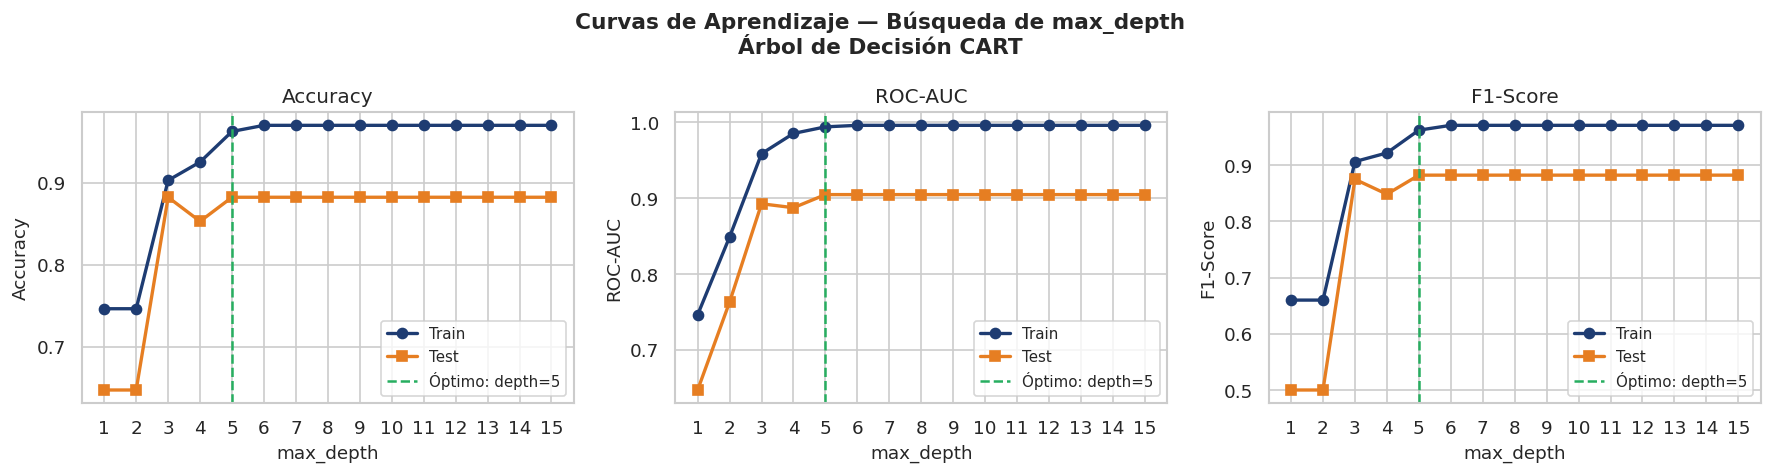

✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_pib.png


In [31]:
# ── CELDA 8: Búsqueda de max_depth óptimo ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

profundidades = range(1, 16)
acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train, f1_test = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)

    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

# Mejor max_depth según F1 en test
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

# ── Gráfico: curvas de entrenamiento vs prueba ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth\nÁrbol de Decisión CART', fontsize=13, fontweight='bold')

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC',  auc_train, auc_test),
    ('F1-Score', f1_train, f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5, label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.savefig('../data/graficas/max_depth_arbol_pib.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_pib.png")

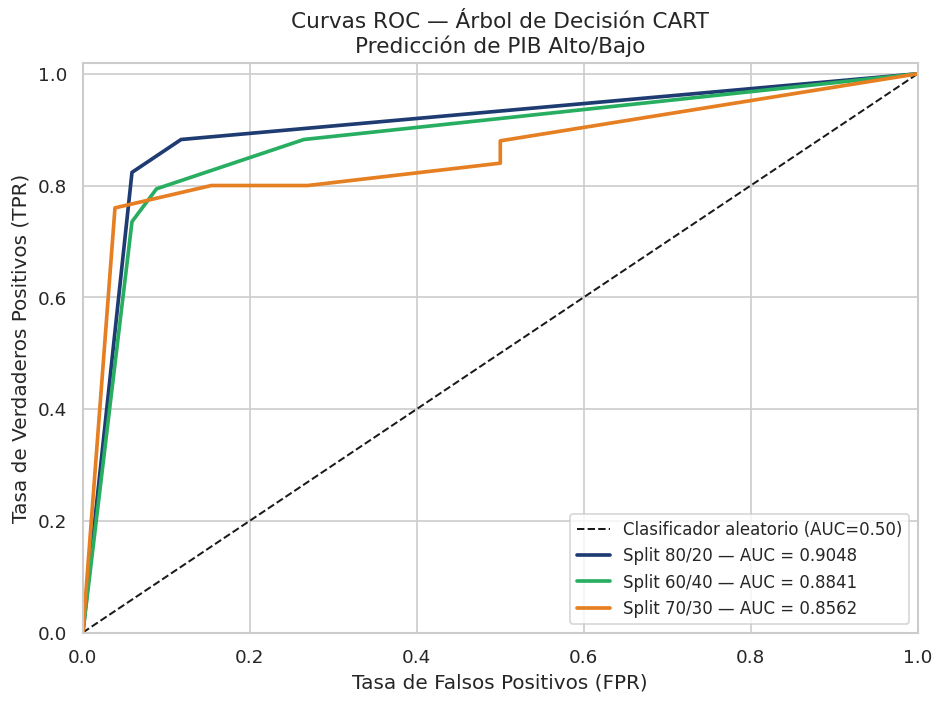

✅ Curvas ROC guardadas en data/graficas/roc_arbol_pib.png


In [32]:
# ── CELDA 9: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión CART\nPredicción de PIB Alto/Bajo', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_arbol_pib.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas ROC guardadas en data/graficas/roc_arbol_pib.png")

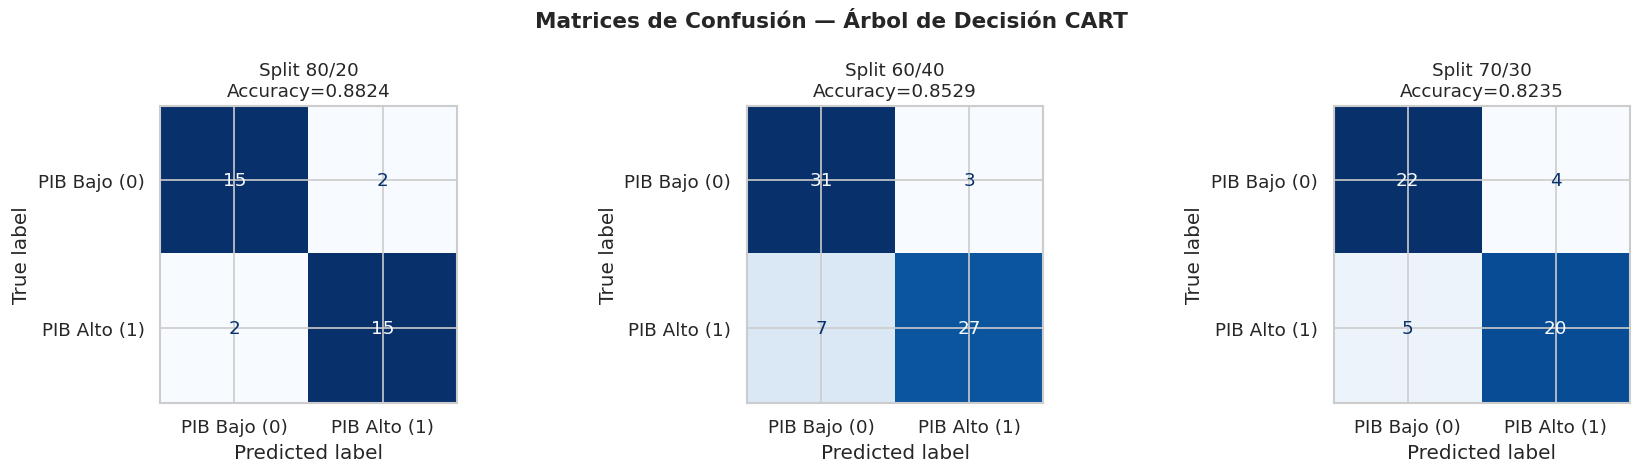

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_pib.png


In [33]:
# ── CELDA 10: Matrices de Confusión (3 splits) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Árbol de Decisión CART', fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['PIB Bajo (0)', 'PIB Alto (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_arbol_pib.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_pib.png")

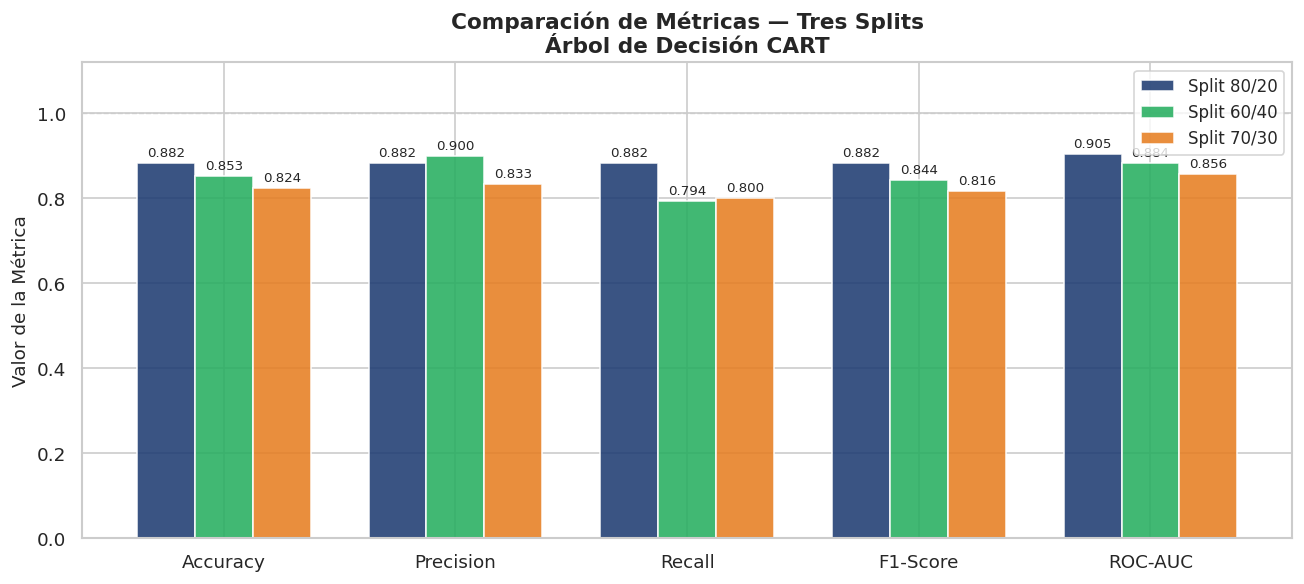

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_pib.png


In [34]:
# ── CELDA 11: Gráfico comparativo de métricas ────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nÁrbol de Decisión CART', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_arbol_pib.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_pib.png")

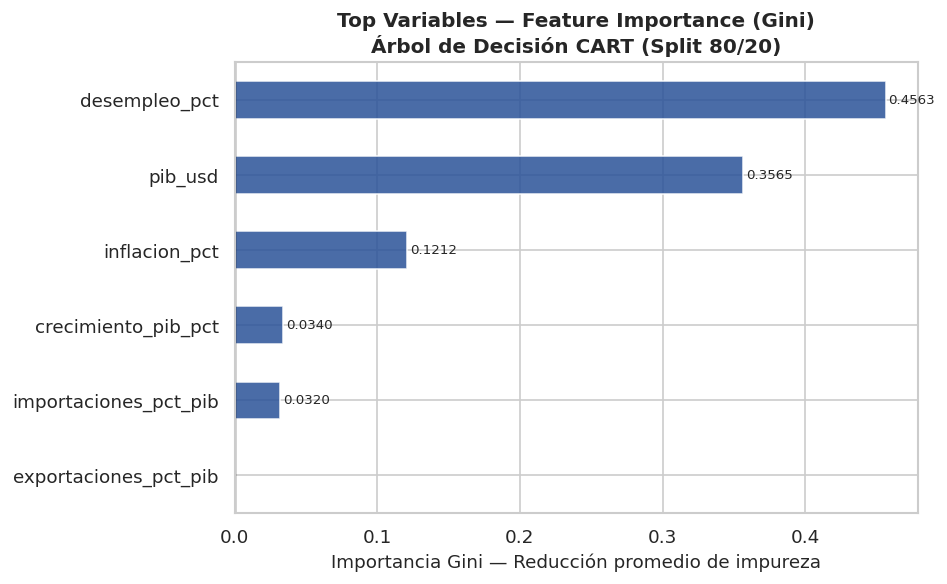

✅ Feature importance guardada en data/graficas/feature_importance_arbol_pib.png

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes:
desempleo_pct            0.456293
pib_usd                  0.356532
inflacion_pct            0.121178
crecimiento_pib_pct      0.034016
importaciones_pct_pib    0.031981


In [35]:
# ── CELDA 12: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref = resultados[0]['modelo']   # Split 80/20
importancias = pd.Series(modelo_ref.feature_importances_, index=X.columns)
importancias_ord = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)
ax.set_title('Top Variables — Feature Importance (Gini)\nÁrbol de Decisión CART (Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar valores
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(width + 0.002, patch.get_y() + patch.get_height() / 2,
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/graficas/feature_importance_arbol_pib.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance guardada en data/graficas/feature_importance_arbol_pib.png")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
print(f"\nTop 5 variables más importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())

In [36]:
# ── CELDA 13: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol de Decisión CART — Clasificación Binaria: PIB Alto/Bajo")
)

                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,134,34,0.8824,0.8824,0.8824,0.8824,0.9048
Split 60/40,100,68,0.8529,0.9000,0.7941,0.8438,0.8841
Split 70/30,117,51,0.8235,0.8333,0.8000,0.8163,0.8562


In [37]:
# ── CELDA 14: Conclusiones ───────────────────────────────────────────────────
print("=" * 65)
print("CONCLUSIONES — ÁRBOL DE DECISIÓN CART (PIB ALTO/BAJO)")
print("=" * 65)

print("""
| Aspecto | Observación |
|---------|-------------|
| **Sin escalado** | Los árboles CART son invariantes al escalado porque dividen en umbrales. |
| **Interpretabilidad** | El árbol puede visualizarse con `plot_tree`. Cada nodo muestra la condición de división. |
| **Feature Importance** | A diferencia de los coeficientes lineales, la importancia Gini mide cuánto reduce cada variable la impureza. |
| **Overfitting** | Los árboles profundos memorizan el entrenamiento. El parámetro `max_depth` controla este trade-off. |
| **`class_weight='balanced'`** | Compensa el desbalance ajustando automáticamente los pesos de clase. |
| **Estabilidad** | Si los tres splits arrojan métricas similares, el modelo generaliza bien. |
""")

print(f"🏆 Mejor max_depth encontrado: {mejor_depth}")
print(f"📊 Mejor F1-Score: {max([r['f1'] for r in resultados]):.4f}")
print(f"📊 Mejor ROC-AUC: {max([r['roc_auc'] for r in resultados]):.4f}")

print("\n✅ NOTEBOOK COMPLETADO — ÁRBOL DE DECISIÓN CART (CLASIFICACIÓN BINARIA)")
print("=" * 65)

CONCLUSIONES — ÁRBOL DE DECISIÓN CART (PIB ALTO/BAJO)

| Aspecto | Observación |
|---------|-------------|
| **Sin escalado** | Los árboles CART son invariantes al escalado porque dividen en umbrales. |
| **Interpretabilidad** | El árbol puede visualizarse con `plot_tree`. Cada nodo muestra la condición de división. |
| **Feature Importance** | A diferencia de los coeficientes lineales, la importancia Gini mide cuánto reduce cada variable la impureza. |
| **Overfitting** | Los árboles profundos memorizan el entrenamiento. El parámetro `max_depth` controla este trade-off. |
| **`class_weight='balanced'`** | Compensa el desbalance ajustando automáticamente los pesos de clase. |
| **Estabilidad** | Si los tres splits arrojan métricas similares, el modelo generaliza bien. |

🏆 Mejor max_depth encontrado: 5
📊 Mejor F1-Score: 0.8824
📊 Mejor ROC-AUC: 0.9048

✅ NOTEBOOK COMPLETADO — ÁRBOL DE DECISIÓN CART (CLASIFICACIÓN BINARIA)
